In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [7]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

speed_threshold = 3
max_freq = 100

# Normalization option: normalize each PSD by sum of power in 20-100 Hz range
normalize_psd = False
norm_freq_range = (1, 100)

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled


In [8]:
# Find and load all psd_spectrogram_state_speed*.npz files
pattern = os.path.join(data_folder, 'CKII**', f'psd_spectrogram_state_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} psd_spectrogram_state files:')
for f in npz_files:
    print(f'  {f}')

# Pool data from all datasets
psd_move_all = []
psd_quiet_all = []
freqs_ref = None

for npz_path in npz_files:
    data = np.load(npz_path)
    freqs = data['freqs']
    psd_move_cells = data['psd_move_cells']
    psd_quiet_cells = data['psd_quiet_cells']
    
    if freqs_ref is None:
        freqs_ref = freqs
    
    # Add all cells from this dataset
    for i in range(psd_move_cells.shape[0]):
        psd_move_all.append(psd_move_cells[i])
        psd_quiet_all.append(psd_quiet_cells[i])
    
    print(f'Loaded {os.path.basename(os.path.dirname(npz_path))}: {psd_move_cells.shape[0]} cells')

# Convert to arrays
psd_move_all = np.array(psd_move_all) if psd_move_all else np.array([])
psd_quiet_all = np.array(psd_quiet_all) if psd_quiet_all else np.array([])

print(f'\nTotal pooled cells: {len(psd_move_all)}')
if freqs_ref is not None:
    print(f'Frequency range: {freqs_ref[0]:.2f} - {freqs_ref[-1]:.2f} Hz')

# Normalize each PSD by sum of power in specified frequency range
if normalize_psd and freqs_ref is not None and len(psd_move_all) > 0:
    norm_mask = (freqs_ref >= norm_freq_range[0]) & (freqs_ref <= norm_freq_range[1])
    print(f'\nNormalizing PSDs by sum of power in {norm_freq_range[0]}-{norm_freq_range[1]} Hz')
    
    for i in range(len(psd_move_all)):
        norm_factor_move = np.nansum(psd_move_all[i, norm_mask])
        norm_factor_quiet = np.nansum(psd_quiet_all[i, norm_mask])
        if norm_factor_move > 0:
            psd_move_all[i] = psd_move_all[i] / norm_factor_move
        if norm_factor_quiet > 0:
            psd_quiet_all[i] = psd_quiet_all[i] / norm_factor_quiet

Found 4 psd_spectrogram_state files:
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce21_PR_20250806/psd_spectrogram_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce45_PX_20260118/psd_spectrogram_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce47_PX_20260128/psd_spectrogram_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/psd_spectrogram_state_speed3.npz
Loaded CKII_pAce21_PR_20250806: 9 cells
Loaded CKII_pAce45_PX_20260118: 16 cells
Loaded CKII_pAce47_PX_20260128: 5 cells
Loaded CKII_pAce38_PX_20251126: 9 cells

Total pooled cells: 39
Frequency range: 1.00 - 100.00 Hz


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_avg_fixedChunks_pooled.svg


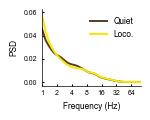

In [9]:
# Plot pooled PSD by behavioral state: Locomotion vs Quiet (spectrogram-based)

run_color = "#f9e800ff"
rest_color = "#563c25"

if len(psd_move_all) > 0 and len(psd_quiet_all) > 0:
    freqs_plot = freqs_ref
    freq_mask = (freqs_plot > 0) & (freqs_plot <= max_freq)
    freqs_plot = freqs_plot[freq_mask]

    # Compute mean and SEM
    psd_move_mean = np.nanmean(psd_move_all, axis=0)[freq_mask]
    psd_move_sem = np.nanstd(psd_move_all, axis=0)[freq_mask] / np.sqrt(len(psd_move_all))
    psd_quiet_mean = np.nanmean(psd_quiet_all, axis=0)[freq_mask]
    psd_quiet_sem = np.nanstd(psd_quiet_all, axis=0)[freq_mask] / np.sqrt(len(psd_quiet_all))
    
    fig, ax = plt.subplots(1, 1, figsize=(1.5,1.2))
    
    # Plot Quiet first (behind)
    ax.plot(freqs_plot, psd_quiet_mean, color=rest_color, linewidth=1.4, label='Quiet')
    ax.fill_between(
        freqs_plot,
        psd_quiet_mean - psd_quiet_sem,
        psd_quiet_mean + psd_quiet_sem,
        color=rest_color,
        alpha=0.2,
        linewidth=0,
    )
    
    # Plot Locomotion (on top)
    ax.plot(freqs_plot, psd_move_mean, color=run_color, linewidth=1.4, label='Loco.')
    ax.fill_between(
        freqs_plot,
        psd_move_mean - psd_move_sem,
        psd_move_mean + psd_move_sem,
        color=run_color,
        alpha=0.2,
        linewidth=0,
    )
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(1, max_freq)
    ticks = [1, 2, 4, 8, 16, 32, 64]
    ticks = [t for t in ticks if t <= max_freq]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_xlabel('Frequency (Hz)')
    ylabel = 'Normalized PSD' if normalize_psd else 'PSD'
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    suffix = '_normalized' if normalize_psd else ''
    out_path = os.path.join(figure_save_folder, f'PSD_state_avg_fixedChunks_pooled{suffix}.svg')
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
    plt.show()
else:
    print('No valid PSD data to plot.')

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_avg_fixedChunks_pooled_theta_zoom_normalized.svg


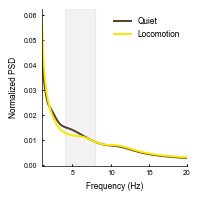

In [6]:
# Plot PSD in theta band (4-8 Hz) zoom

theta_band = (4, 8)

if len(psd_move_all) > 0 and len(psd_quiet_all) > 0:
    freqs_plot = freqs_ref
    freq_mask = (freqs_plot > 0) & (freqs_plot <= 20)
    freqs_plot_zoom = freqs_plot[freq_mask]

    # Compute mean and SEM
    psd_move_mean = np.nanmean(psd_move_all, axis=0)[freq_mask]
    psd_move_sem = np.nanstd(psd_move_all, axis=0)[freq_mask] / np.sqrt(len(psd_move_all))
    psd_quiet_mean = np.nanmean(psd_quiet_all, axis=0)[freq_mask]
    psd_quiet_sem = np.nanstd(psd_quiet_all, axis=0)[freq_mask] / np.sqrt(len(psd_quiet_all))
    
    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    
    # Plot Quiet first (behind)
    ax.plot(freqs_plot_zoom, psd_quiet_mean, color=rest_color, linewidth=1.4, label='Quiet')
    ax.fill_between(
        freqs_plot_zoom,
        psd_quiet_mean - psd_quiet_sem,
        psd_quiet_mean + psd_quiet_sem,
        color=rest_color,
        alpha=0.2,
        linewidth=0,
    )
    
    # Plot Locomotion (on top)
    ax.plot(freqs_plot_zoom, psd_move_mean, color=run_color, linewidth=1.4, label='Locomotion')
    ax.fill_between(
        freqs_plot_zoom,
        psd_move_mean - psd_move_sem,
        psd_move_mean + psd_move_sem,
        color=run_color,
        alpha=0.2,
        linewidth=0,
    )
    
    # Highlight theta band
    ax.axvspan(theta_band[0], theta_band[1], alpha=0.1, color='gray')
    
    ax.set_xlim(1, 20)
    ax.set_xlabel('Frequency (Hz)')
    ylabel = 'Normalized PSD' if normalize_psd else 'PSD'
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    suffix = '_normalized' if normalize_psd else ''
    out_path = os.path.join(figure_save_folder, f'PSD_state_avg_fixedChunks_pooled_theta_zoom{suffix}.svg')
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
    plt.show()
else:
    print('No valid PSD data to plot.')

In [22]:
# Print summary statistics and compare theta power
print('\n=== Summary Statistics ===')
print(f'Total pooled cells: {len(psd_move_all)}')
if normalize_psd:
    print(f'PSDs normalized by sum of power in {norm_freq_range[0]}-{norm_freq_range[1]} Hz')

if len(psd_move_all) > 0 and freqs_ref is not None:
    # Extract theta band power (4-8 Hz)
    theta_mask = (freqs_ref >= 4) & (freqs_ref <= 8)
    
    theta_power_move = np.nanmean(psd_move_all[:, theta_mask], axis=1)
    theta_power_quiet = np.nanmean(psd_quiet_all[:, theta_mask], axis=1)
    
    print(f'\nTheta power (4-8 Hz):')
    print(f'  Locomotion: mean={np.nanmean(theta_power_move):.4f}, std={np.nanstd(theta_power_move):.4f}')
    print(f'  Quiet: mean={np.nanmean(theta_power_quiet):.4f}, std={np.nanstd(theta_power_quiet):.4f}')
    
    # Paired test on theta power
    valid = np.isfinite(theta_power_move) & np.isfinite(theta_power_quiet)
    if np.sum(valid) >= 3:
        diffs = theta_power_move[valid] - theta_power_quiet[valid]
        try:
            shapiro_p = stats.shapiro(diffs).pvalue
        except ValueError:
            shapiro_p = np.nan
        
        if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
            result = stats.ttest_rel(theta_power_move[valid], theta_power_quiet[valid])
            test_name = 'paired t-test'
        else:
            result = stats.wilcoxon(theta_power_move[valid], theta_power_quiet[valid])
            test_name = 'wilcoxon'
        
        print(f'\nTheta power comparison ({test_name}):')
        print(f'  n={np.sum(valid)}, stat={result.statistic:.3g}, p={result.pvalue:.3g}')


=== Summary Statistics ===
Total pooled cells: 39
PSDs normalized by sum of power in 20-100 Hz

Theta power (4-8 Hz):
  Locomotion: mean=0.1331, std=0.0838
  Quiet: mean=0.1995, std=0.1591

Theta power comparison (wilcoxon):
  n=39, stat=53, p=1.64e-07
